In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Khám phá dữ liệu

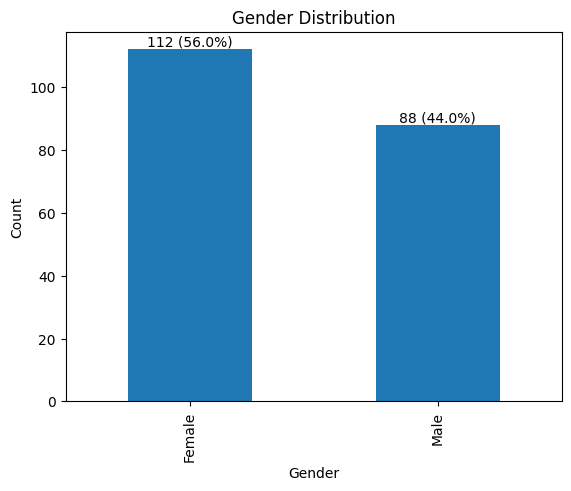

In [ ]:
#Phân bố giới tính
counts = df['Gender'].value_counts()
total = counts.sum()

ax = counts.plot(kind='bar')

for p in ax.patches:
    value = int(p.get_height())
    percent = value / total * 100
    ax.annotate(
        f"{value} ({percent:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()



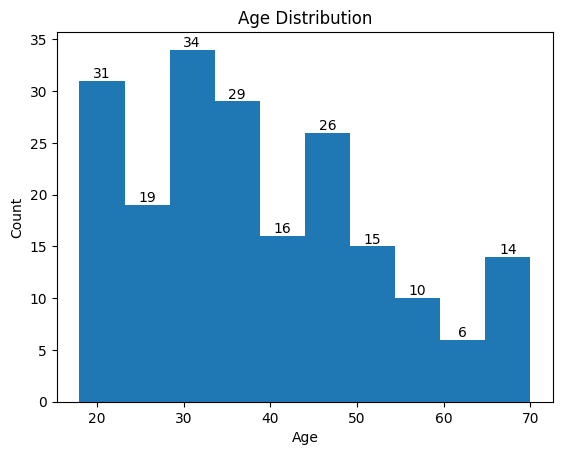

In [ ]:
#Phân bố tuổi
counts, bins, patches = plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

for count, left, right, patch in zip(counts, bins[:-1], bins[1:], patches):
    if count > 0:
        x = (left + right) / 2
        plt.text(x, count, f"{int(count)}", ha='center', va='bottom')

plt.show()



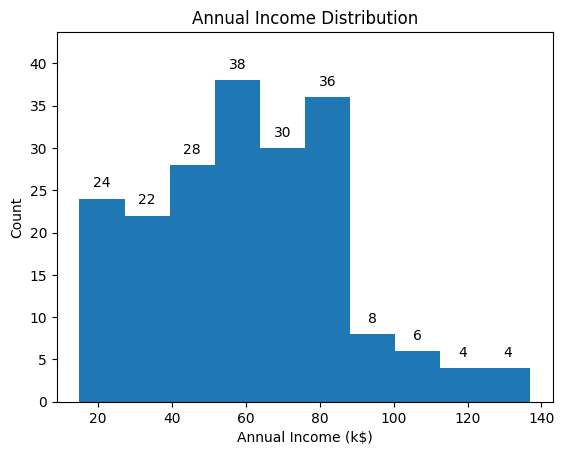

In [ ]:
#Phân bố thu nhập hằng năm
counts, bins, patches = plt.hist(df['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

max_count = max(counts)
plt.ylim(0, max_count * 1.15)

for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        plt.text(x, count + 1, int(count), ha='center', va='bottom')

plt.show()


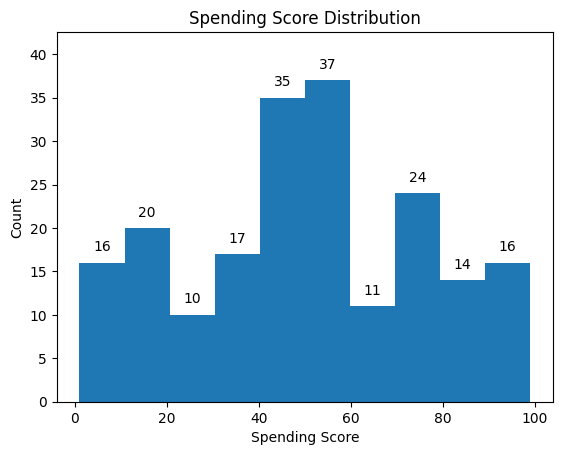

In [ ]:
counts, bins, patches = plt.hist(df['Spending Score (1-100)'], bins=10)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

max_count = max(counts)
plt.ylim(0, max_count * 1.15)

for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        plt.text(x, count + 1, int(count), ha='center', va='bottom')

plt.show()


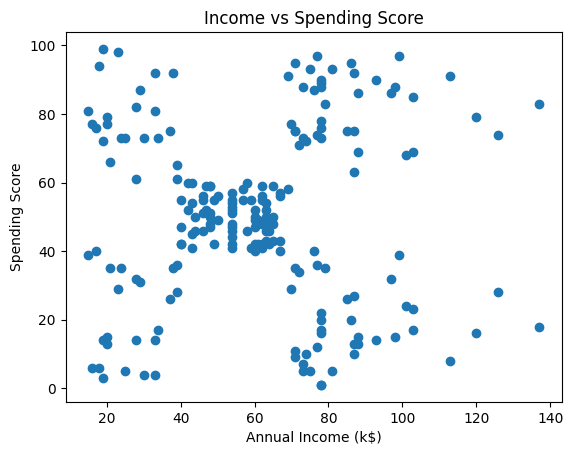

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Phương pháp Elbow

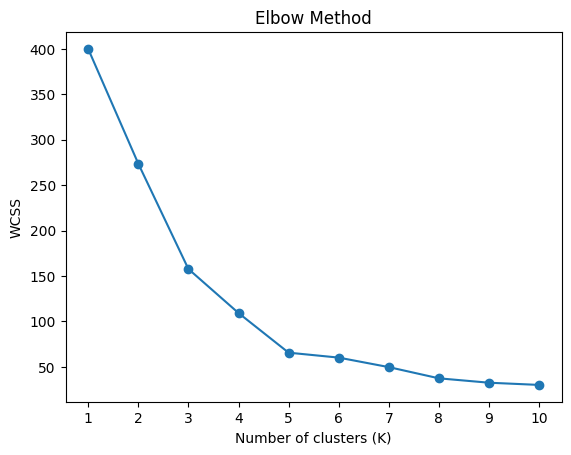

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.xticks(range(1, 11), labels=[f"{i}" for i in range(1, 11)])

plt.show()


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)


metric đánh giá

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

Ks = [4, 5, 6, 7]

print("K\tSilhouette\tDavies-Bouldin Index")
print("-" * 40)

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)

    print(f"{k}\t{sil:.4f}\t\t{dbi:.4f}")


K	Silhouette	Davies-Bouldin Index
----------------------------------------
4	0.4943		0.6975
5	0.5547		0.5722
6	0.5138		0.6239
7	0.5020		0.6925


Phân cụm khách hàng

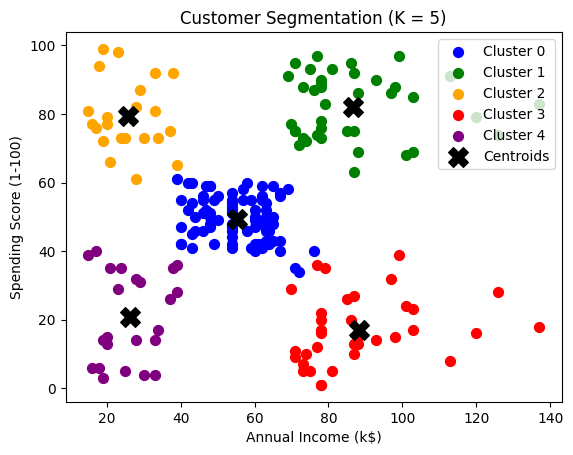

In [ ]:

# Chọn 2 biến để phân cụm
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# KMeans với K = 5 (CỐ ĐỊNH)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# Màu cố định cho từng cụm
colors = ['blue', 'green', 'orange', 'red', 'purple']

# Vẽ từng cụm
for i in range(5):
    plt.scatter(
        X.iloc[labels == i, 0],
        X.iloc[labels == i, 1],
        s=50,
        color=colors[i],
        label=f'Cluster {i}'
    )

# Vẽ tâm cụm
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation (K = 5)")
plt.legend(loc='upper right')
plt.show()


In [ ]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

centroids = kmeans.cluster_centers_
print(centroids)


[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]
